# Heteroscedastic mixed-variable BO — 3-method comparison

| study | model of the 5 categories | shares? |
|---|---|---|
| `study_v2` (LVGP) | one latent-variable GP | yes |
| `study_v2_gp` | 5 independent GPs | **no** |
| `study_v2_cat` (Method C) | one MixedSingleTaskGP + CategoricalKernel | yes |

**Kernel: ml_gp_env.**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys; sys.path.insert(0, os.path.abspath("study_v2_cat"))
%matplotlib inline
import numpy as np, pandas as pd
from utils import StudyResults, compare_studies_multi, compare_summary_heatmaps, problem
from utils.results import _metric_trajectories, _cfg_param

lvgp = StudyResults.load("study_v2/results"); gp = StudyResults.load("study_v2_gp/results")
cat  = StudyResults.load("study_v2_cat/results")
studies = [(lvgp, "LVGP"), (gp, "Per-category GP"), (cat, "Categorical GP")]
print({lab: len(s.runs) for s, lab in studies}, "runs | f* =", round(problem.ground_truth_min(),4))

{'LVGP': 1080, 'Per-category GP': 1080, 'Categorical GP': 1080} runs | f* = 0.4651


## The single toggle: `GROUND_TRUTH`
This **one boolean drives every comparison below** — the convergence overlay *and* the summary
heatmap now use the **same** definition of "best design", so they're consistent:

- **`GROUND_TRUTH = True`** — the design with the lowest **TRUE** objective among all sampled
  points (`min_i f_true(x_i)`); never uses the noisy mean.
- **`GROUND_TRUTH = False`** — the design with the lowest **NOISY** sample-mean (what BO would
  recommend); can read below f\* at small n_rep.

In [2]:
GROUND_TRUTH = True      # <-- flip to False to view the noisy-mean versions of every plot below

### Final value of the best design (table)

In [3]:
def final_value_table(studies, n_rep=10):
    metric = "true" if GROUND_TRUTH else "noisy"
    cols = {}
    for s, lab in studies:
        t = _metric_trajectories(s, metric, n_rep, as_regret=False)         # raw best VALUE
        cols[lab] = {problem.label(c[0], _cfg_param(c)): v[1][-1] for c, v in t.items()}
    order = [problem.label(a, p) for a, p in problem.CONFIG_ORDER]
    return pd.DataFrame(cols).reindex([o for o in order if o in pd.DataFrame(cols).index])

print(("f* = %.4f (all >= f*)" % problem.ground_truth_min()) if GROUND_TRUTH else "noisy values (can be < f*)")
final_value_table(studies, n_rep=10).round(4)

f* = 0.4651 (all >= f*)


,LVGP,Per-category GP,Categorical GP
LCB,0.5532,0.4824,0.5753
PI,1.5105,1.0282,0.6123
EI,0.5025,2.4193,0.5862
HAEI(γ=0.5),0.4678,0.5623,0.5664
HAEI(γ=1),0.4698,0.4822,0.5338
HAEI(γ=5),0.4739,0.4709,0.5113
ANPEI(β=0.2),1.2978,1.6305,1.5548
ANPEI(β=0.5),0.5193,2.2771,0.5159
ANPEI(β=0.8),0.4660,2.1074,0.5300
RAHBO(α=0.5),0.4672,0.4727,0.4962


### Convergence overlay (regret = value − f* when GROUND_TRUTH, log axis)

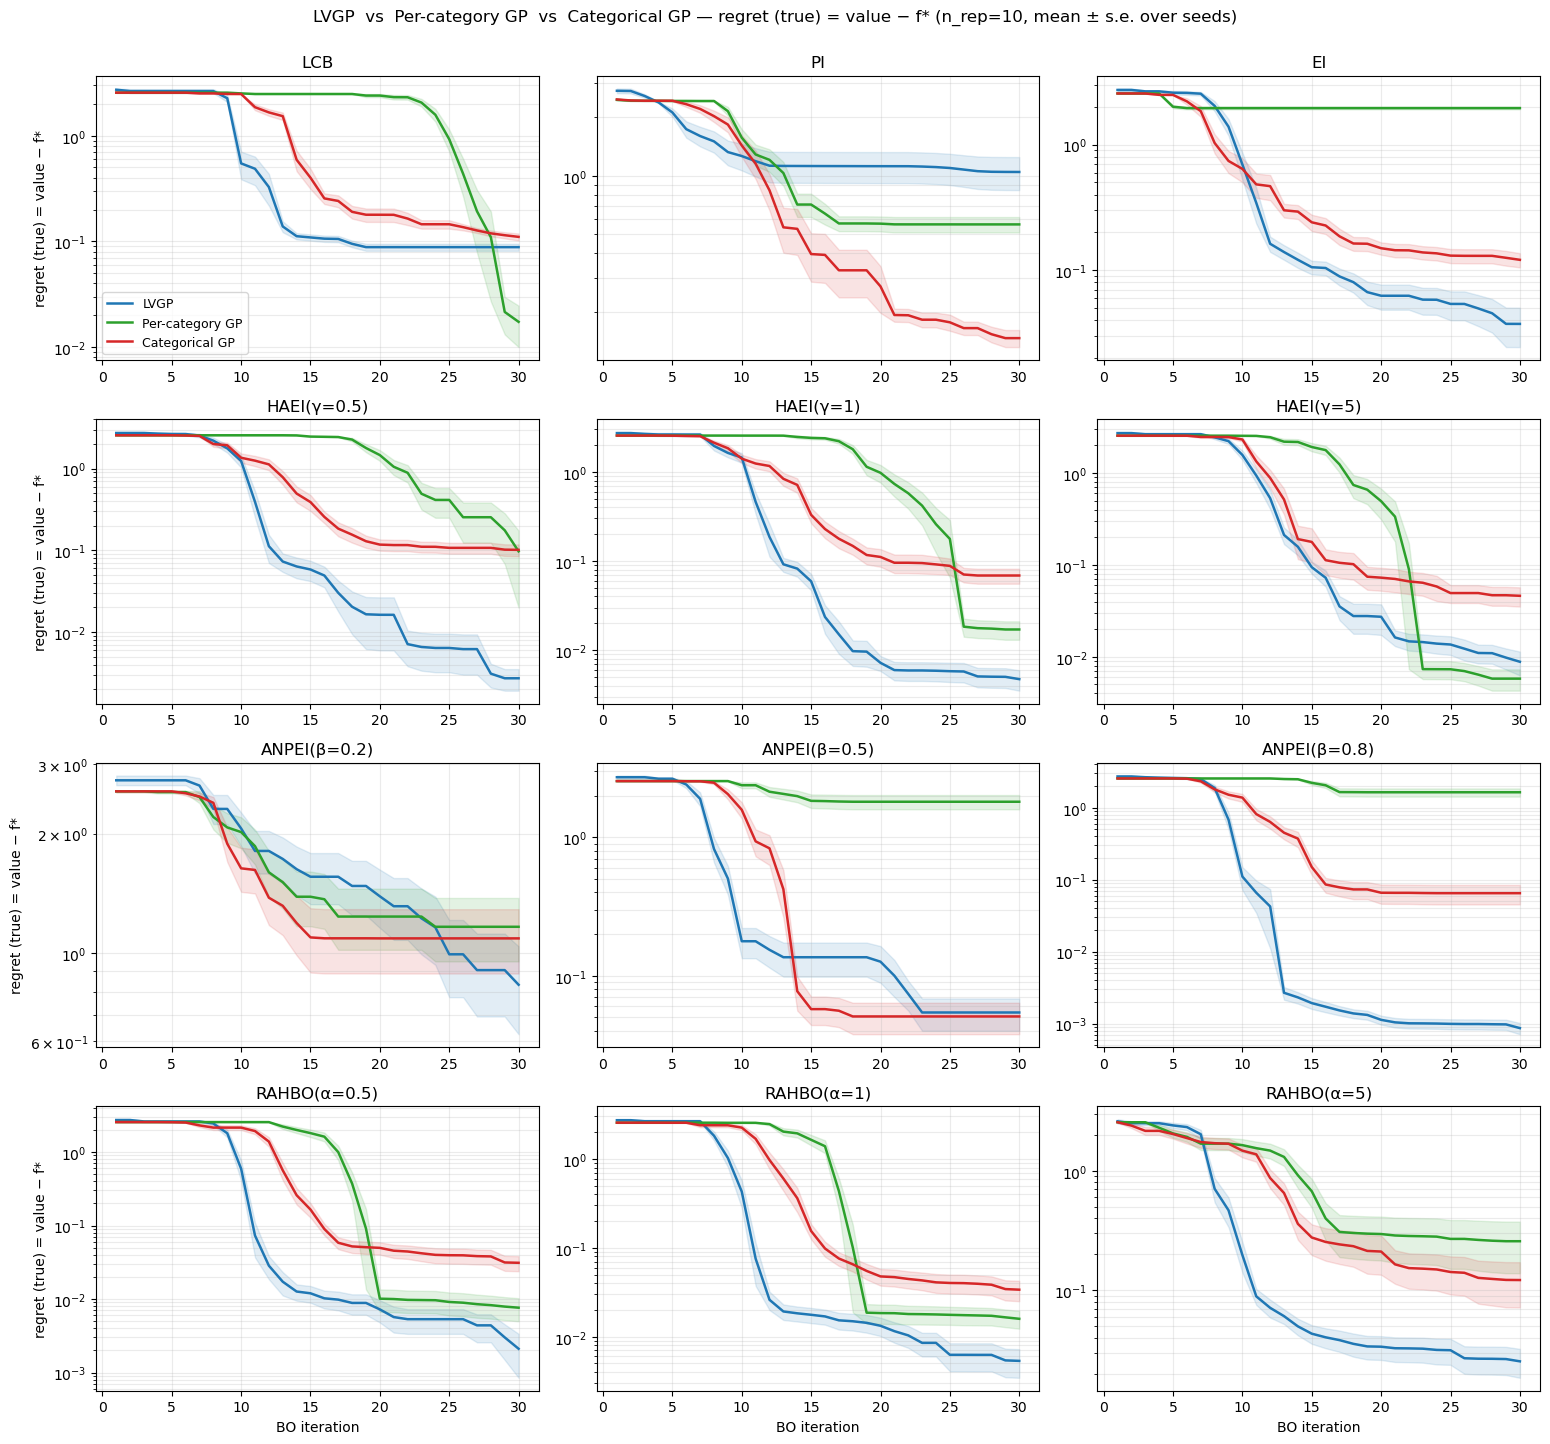

In [4]:
compare_studies_multi(studies, is_ground_truth=GROUND_TRUTH, n_rep=10)

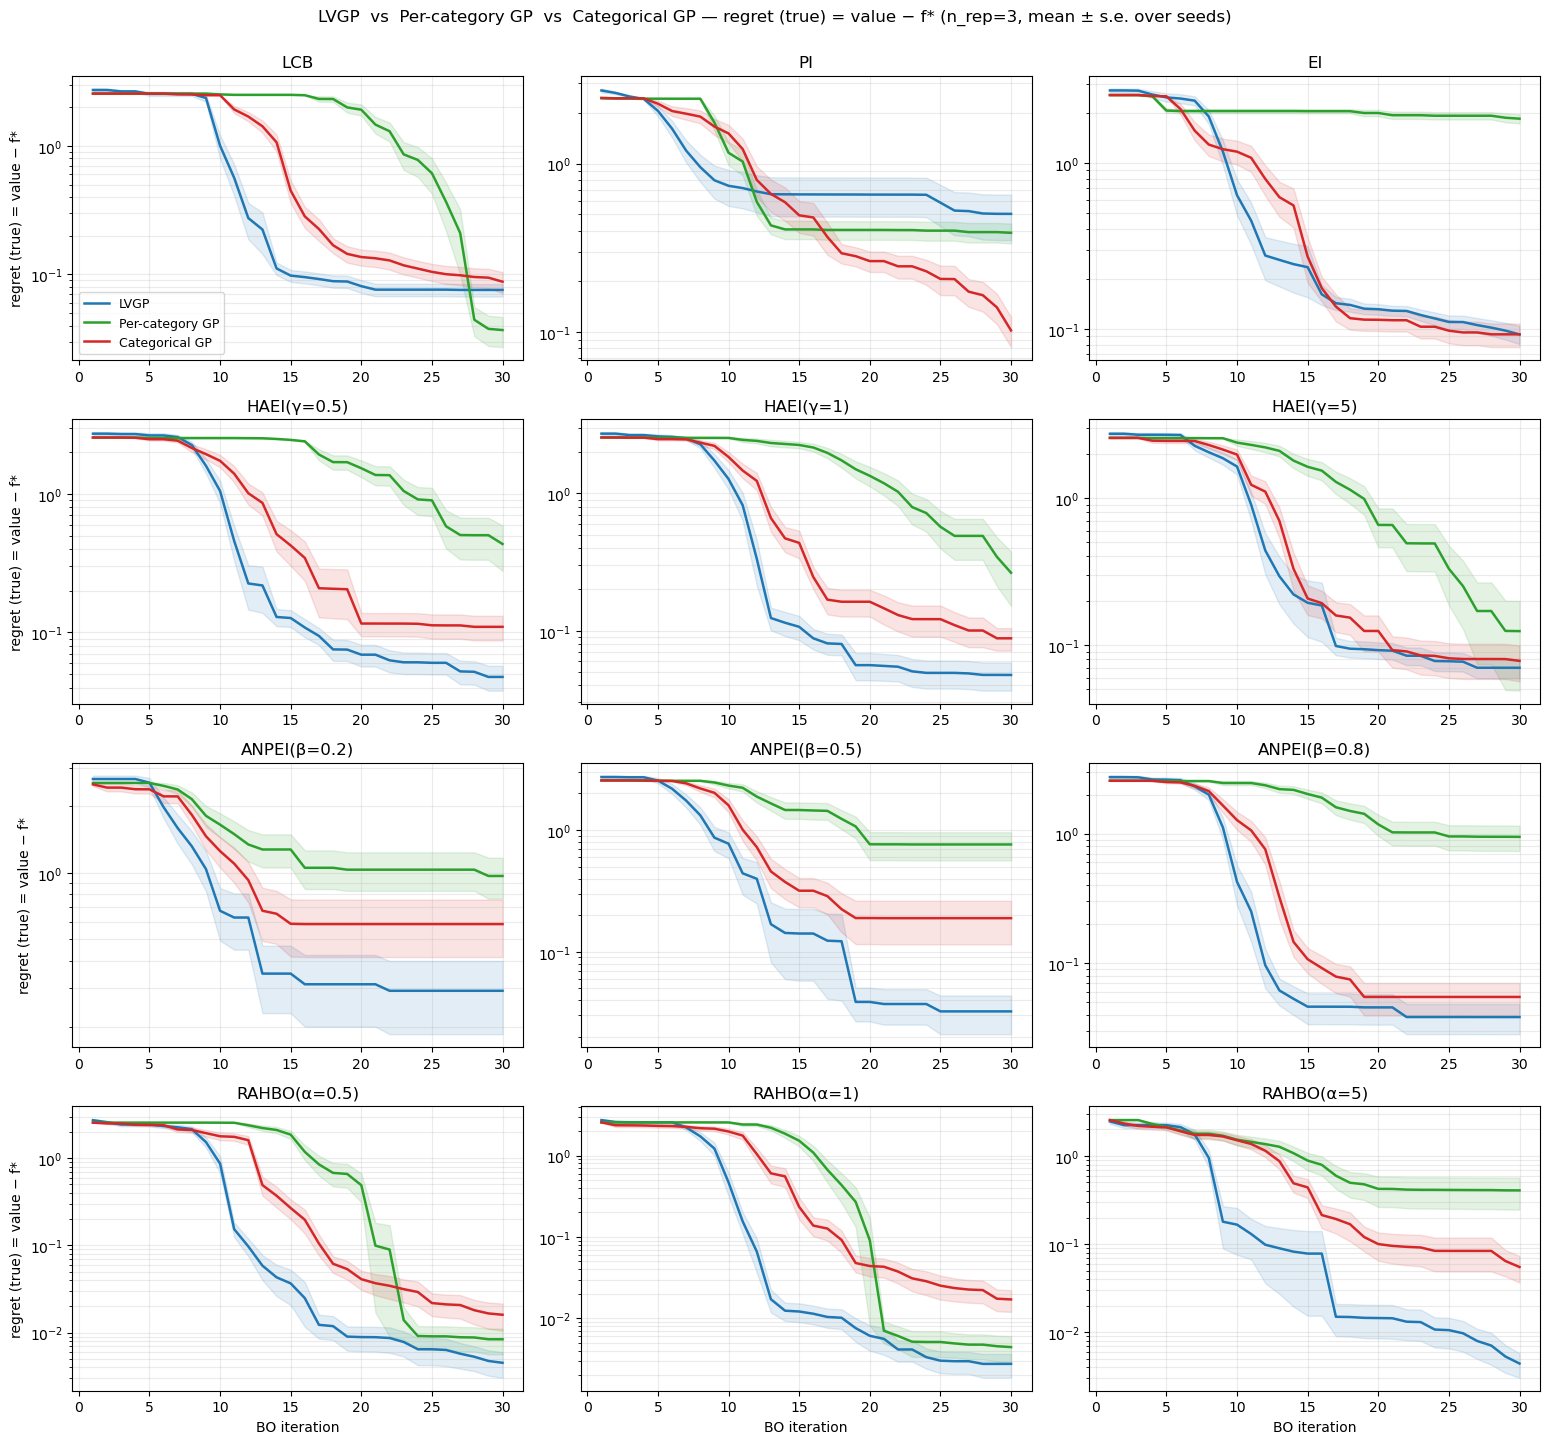

In [5]:
compare_studies_multi(studies, is_ground_truth=GROUND_TRUTH, n_rep=3)

### Summary heatmaps — SAME selection, so the final-iteration values match the table above

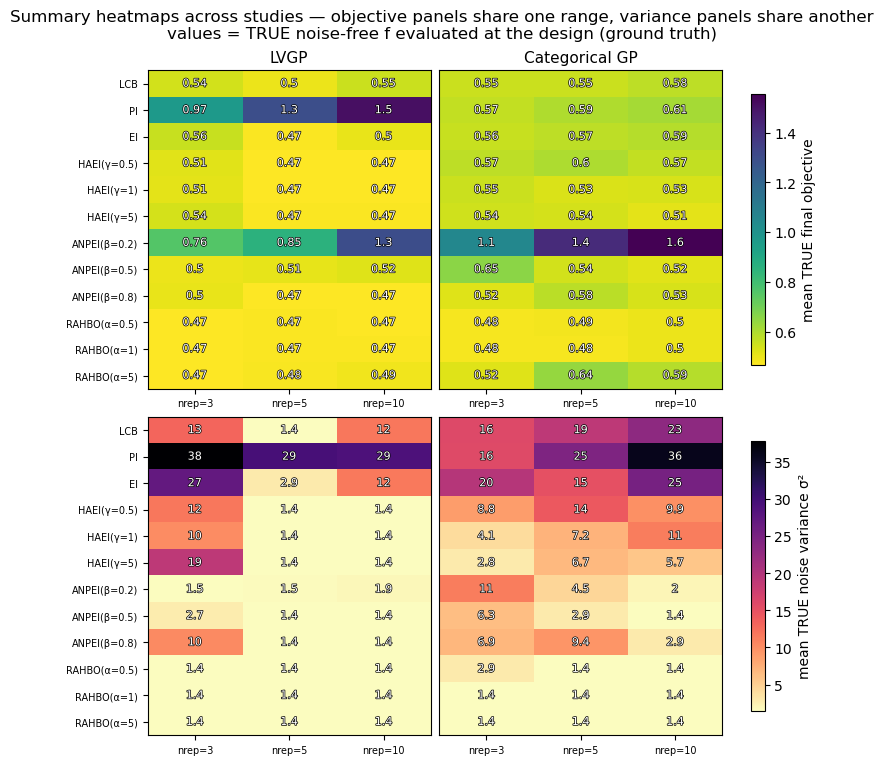

In [9]:
# heatmap column order: LVGP, Categorical (both share across categories), then Per-category (no sharing) in the corner
heatmap_order = [(lvgp, "LVGP"), (cat, "Categorical GP")]#, (gp, "Per-category GP")]
compare_summary_heatmaps(heatmap_order, is_ground_truth=GROUND_TRUTH)

### Pairwise (categorical GP vs each)

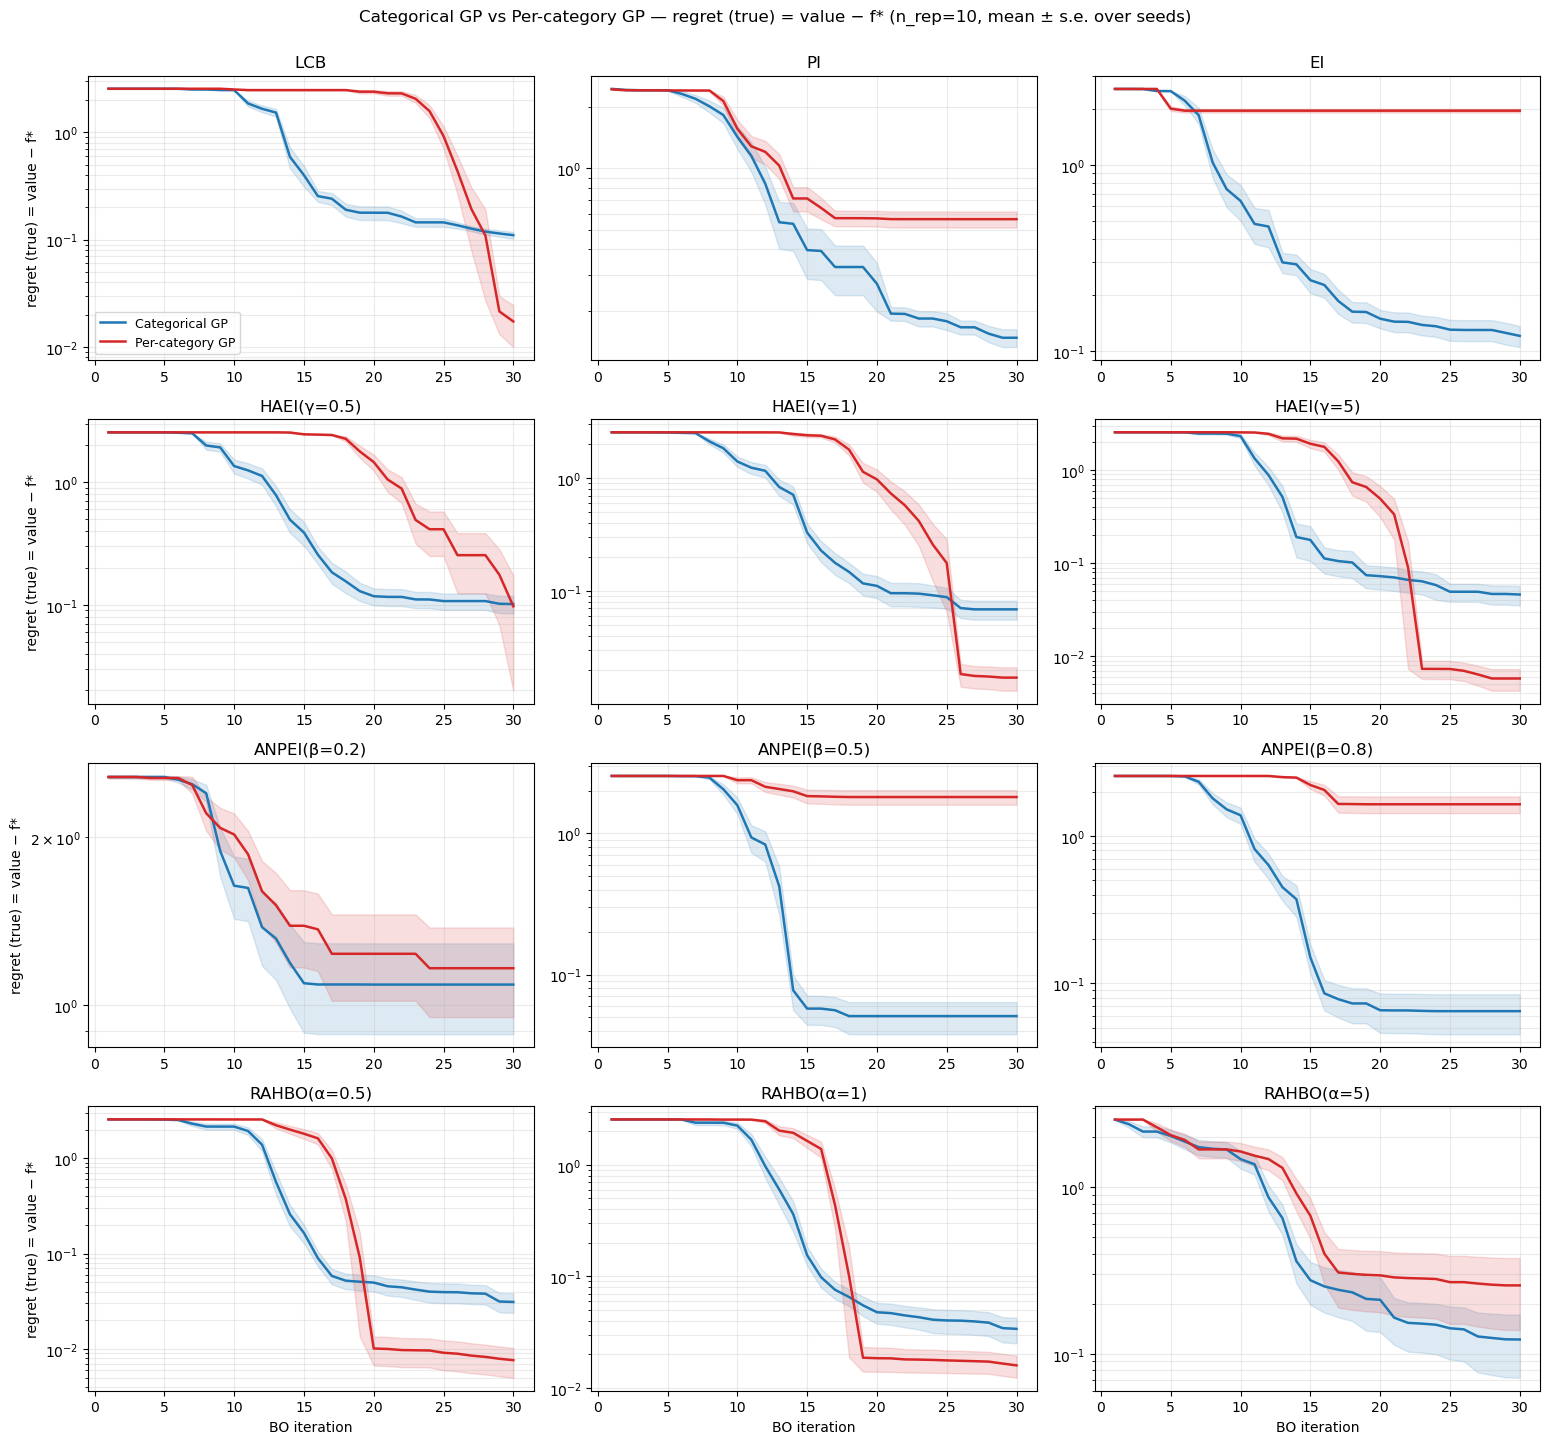

In [7]:
from utils import compare_studies
compare_studies(cat, gp,   is_ground_truth=GROUND_TRUTH, n_rep=10, labels=("Categorical GP", "Per-category GP"))

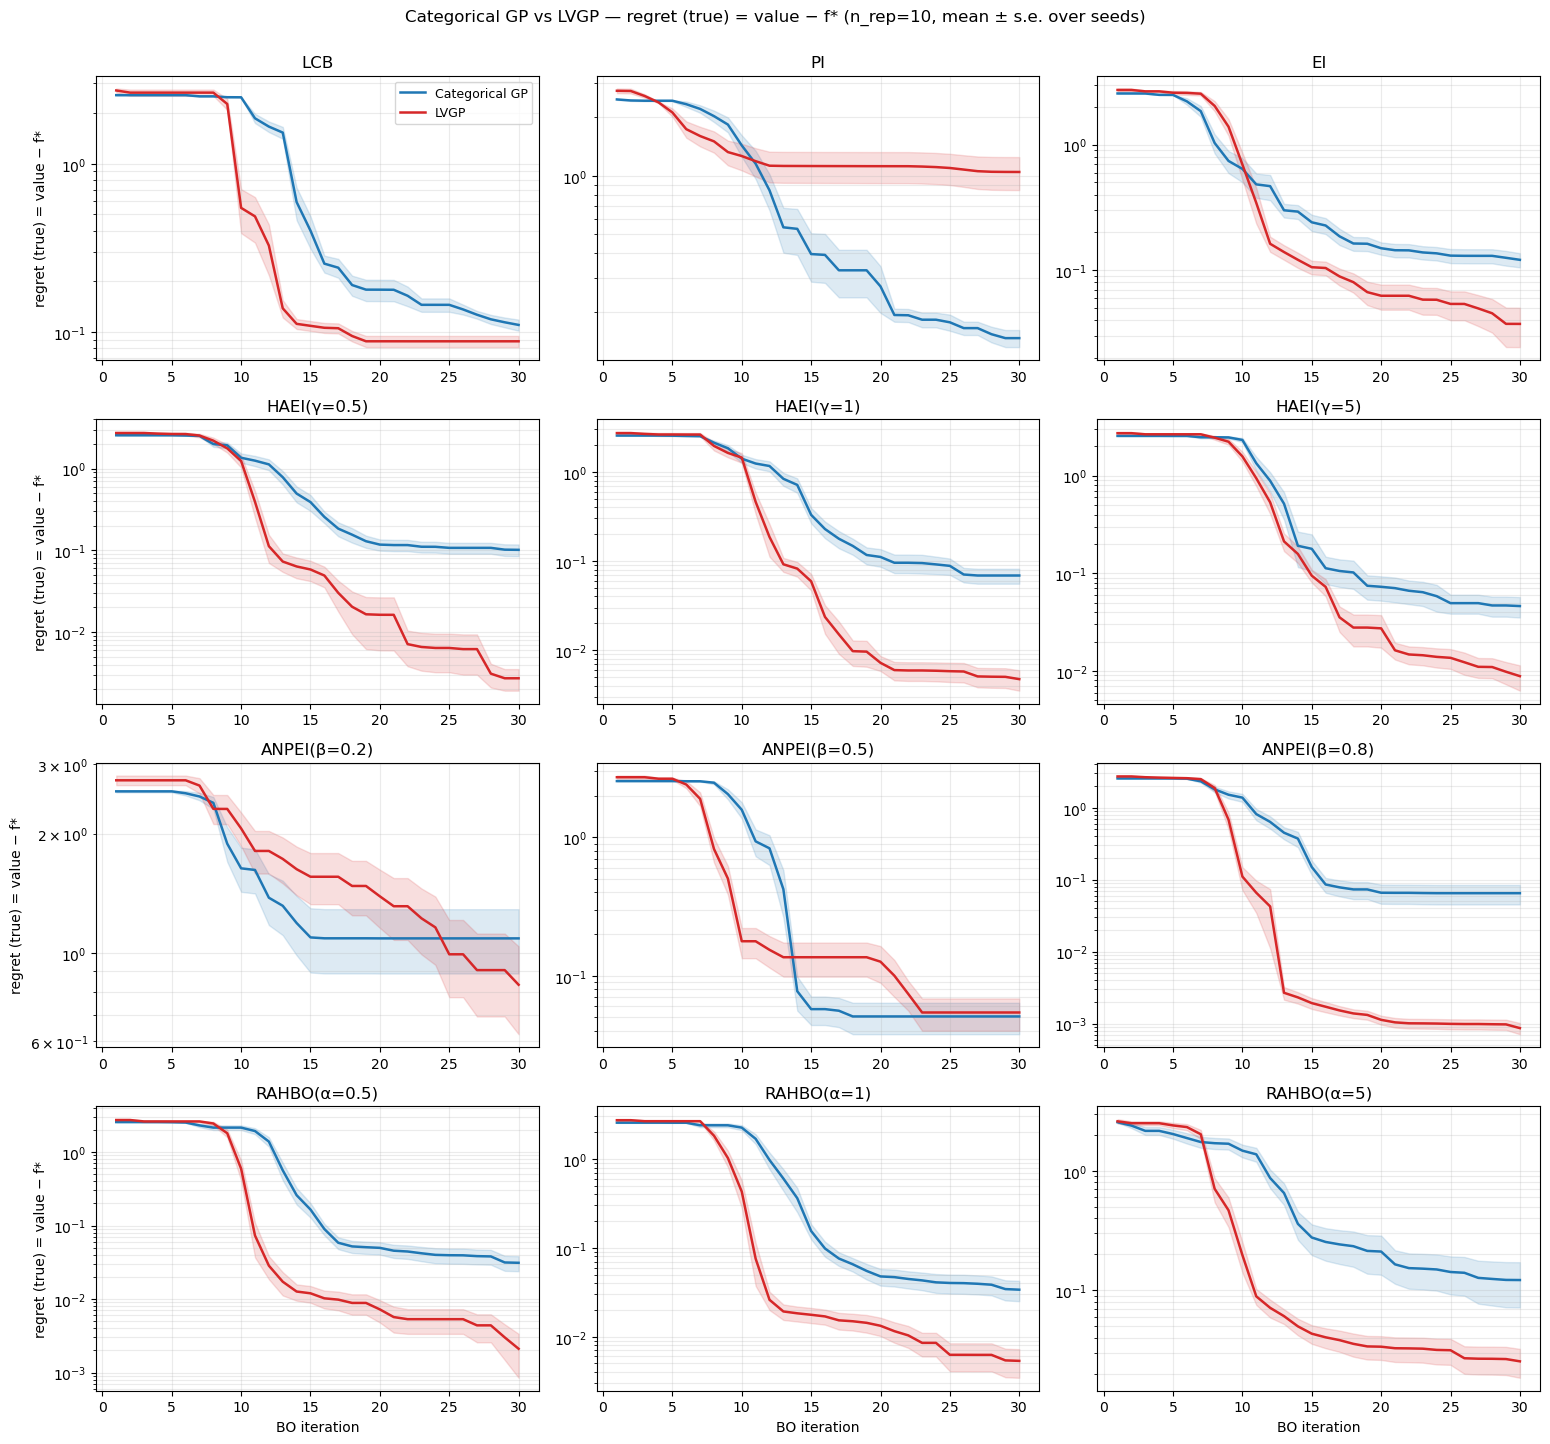

In [8]:
compare_studies(cat, lvgp, is_ground_truth=GROUND_TRUTH, n_rep=10, labels=("Categorical GP", "LVGP"))